# Introduction aux réseaux neuronaux

## Comprendre les grands principes avant de passer à Keras

> **Objectif de la séance :** comprendre intuitivement comment fonctionne un réseau neuronal, comment il apprend et comment interpréter les principales étapes d'un entraînement.

## 0. Préparation de l'environnement

Nous allons utiliser principalement :

- NumPy pour les calculs numériques ;
- Pandas pour manipuler les données ;
- Matplotlib pour les visualisations ;
- scikit-learn pour quelques démonstrations ;
- TensorFlow / Keras pour construire un réseau neuronal.

### Imports

In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix

plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.grid'] = True

## Une question simple

Imaginons que nous disposions d'observations décrites par plusieurs caractéristiques.

Nous voulons déterminer automatiquement à quelle catégorie appartient une nouvelle observation.

```mermaid
flowchart TB
    FEATURES["Caractéristiques"] --> MODEL["Modèle de Machine Learning"]
    MODEL --> PREDICTION["Prédiction"]

    classDef data fill:#E8F1FB,stroke:#2F6FED,color:#16345C,stroke-width:1.5px
    classDef model fill:#E6F4F1,stroke:#138A72,color:#12453B,stroke-width:1.5px
    classDef prediction fill:#FFF3D6,stroke:#C58A00,color:#5C4200,stroke-width:1.5px
    class FEATURES data
    class MODEL model
    class PREDICTION prediction
```

Le modèle ne reçoit pas une règle écrite explicitement.

Il reçoit des exemples :

```text
Entrées de l'observation       Réponse attendue

x⁽¹⁾₁, x⁽¹⁾₂, x⁽¹⁾₃, x⁽¹⁾₄   ───────►      y⁽¹⁾ = 0
x⁽²⁾₁, x⁽²⁾₂, x⁽²⁾₃, x⁽²⁾₄   ───────►      y⁽²⁾ = 1
x⁽³⁾₁, x⁽³⁾₂, x⁽³⁾₃, x⁽³⁾₄   ───────►      y⁽³⁾ = 0
...
```

L'objectif est de découvrir une relation entre les entrées et la sortie.

## Un réseau neuronal est un modèle paramétrique

Un réseau neuronal contient des paramètres numériques, principalement :

- des **poids** ;
- des **biais**.

Pendant l'apprentissage, ces paramètres sont ajustés pour réduire les erreurs de prédiction.

```mermaid
flowchart LR
    DATA["Données"] --> MODEL["Réseau neuronal"]
    MODEL --> PRED["Prédiction"]
    PRED --> ERROR["Erreur"]
    ERROR --> UPDATE["Ajustement des paramètres"]
    UPDATE --> MODEL

    classDef data fill:#E8F1FB,stroke:#2F6FED,color:#16345C,stroke-width:1.5px
    classDef model fill:#E6F4F1,stroke:#138A72,color:#12453B,stroke-width:1.5px
    classDef prediction fill:#FFF3D6,stroke:#C58A00,color:#5C4200,stroke-width:1.5px
    classDef error fill:#FDE8E7,stroke:#C2413B,color:#6B201C,stroke-width:1.5px
    classDef optimization fill:#EDEBFA,stroke:#5B4BB7,color:#30256B,stroke-width:1.5px
    class DATA data
    class MODEL model
    class PRED prediction
    class ERROR error
    class UPDATE optimization
```

### À retenir

> Un réseau neuronal n'est pas une boîte magique : c'est un ensemble de calculs paramétrés dont les paramètres sont ajustés à partir des données.



# 2. Le neurone artificiel

## Une version simplifiée

Un neurone artificiel reçoit plusieurs entrées.

Chaque entrée est associée à un poids.

```mermaid
flowchart LR
    X1["Entrée x₁"] --> W1["× poids w₁"]
    X2["Entrée x₂"] --> W2["× poids w₂"]
    X3["Entrée x₃"] --> W3["× poids w₃"]

    W1 --> SUM["Somme pondérée"]
    W2 --> SUM
    W3 --> SUM
    B["Biais b"] --> SUM

    subgraph NEURON["Neurone artificiel"]
        SUM --> ACT["Fonction d'activation"]
    end
    ACT --> Y["Sortie"]

    classDef input fill:#E8F1FB,stroke:#2F6FED,color:#16345C,stroke-width:1.5px
    classDef parameter fill:#F3F4F6,stroke:#64748B,color:#334155,stroke-width:1.5px
    classDef process fill:#E6F4F1,stroke:#138A72,color:#12453B,stroke-width:1.5px
    classDef prediction fill:#FFF3D6,stroke:#C58A00,color:#5C4200,stroke-width:1.5px
    classDef neuron fill:#F0FAF7,stroke:#138A72,color:#12453B,stroke-width:1.5px
    class X1,X2,X3 input
    class W1,W2,W3,B parameter
    class SUM,ACT process
    class Y prediction
    class NEURON neuron
```

Le neurone calcule d'abord :

$$
z = w_1x_1 + w_2x_2 + w_3x_3 + b
$$

Puis applique une fonction d'activation :

$$
y = f(z)
$$

## Que représentent les poids ?

Les poids permettent au neurone de pondérer les différentes entrées.

Un poids positif important peut renforcer l'influence d'une variable.

Un poids proche de zéro peut avoir une influence limitée.

Un poids négatif peut avoir une influence dans la direction opposée.


Au début, les poids sont initialisés automatiquement.

Pendant l'apprentissage, le réseau les ajuste.

# 3. Une petite expérience avec un neurone

Nous pouvons observer l'effet de poids différents.

In [65]:
def neuron_output(x1, x2, w1, w2, b):
    """Calcule la sortie linéaire d'un neurone."""
    return w1 * x1 + w2 * x2 + b


examples = [
    {'w1': 1.0, 'w2': 1.0, 'b': 0.0},
    {'w1': 3.0, 'w2': 0.5, 'b': 0.0},
    {'w1': -1.0, 'w2': 2.0, 'b': 0.0},
]

x1 = 2
x2 = 3

for example in examples:
    output = neuron_output(
        x1,
        x2,
        example['w1'],
        example['w2'],
        example['b']
    )
    print(
        f"w1={example['w1']}, "
        f"w2={example['w2']} → sortie={output:.2f}"
    )

w1=1.0, w2=1.0 → sortie=5.00
w1=3.0, w2=0.5 → sortie=7.50
w1=-1.0, w2=2.0 → sortie=4.00


### Question

La même observation peut donc produire des sorties différentes simplement parce que les poids sont différents.

C'est précisément ce que l'apprentissage va permettre d'ajuster.

# 4. De la combinaison linéaire à la décision

Un neurone sans fonction d'activation effectue essentiellement une transformation linéaire.

Pour deux variables :

$$
z = w_1x_1 + w_2x_2 + b
$$

La frontière correspondant à `z = 0` est :

$$
w_1x_1 + w_2x_2 + b = 0
$$

Nous pouvons la visualiser.

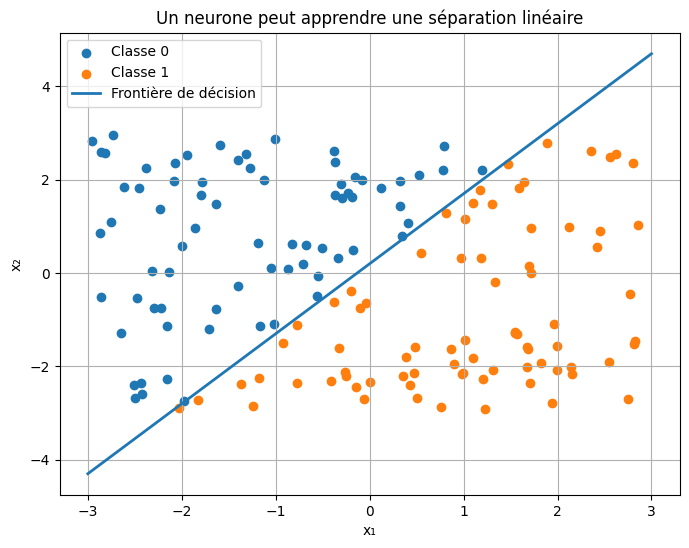

In [66]:
rng = np.random.default_rng(42)

x1_values = rng.uniform(-3, 3, 150)
x2_values = rng.uniform(-3, 3, 150)

w1 = 1.5
w2 = -1.0
b = 0.2

z = w1 * x1_values + w2 * x2_values + b
labels = (z >= 0).astype(int)

plt.figure(figsize=(8, 6))
plt.scatter(
    x1_values[labels == 0],
    x2_values[labels == 0],
    label='Classe 0'
)
plt.scatter(
    x1_values[labels == 1],
    x2_values[labels == 1],
    label='Classe 1'
)

x_line = np.linspace(-3, 3, 100)
y_line = -(w1 * x_line + b) / w2

plt.plot(
    x_line,
    y_line,
    linewidth=2,
    label='Frontière de décision'
)

plt.xlabel('x₁')
plt.ylabel('x₂')
plt.title('Un neurone peut apprendre une séparation linéaire')
plt.legend()
plt.show()

### Idée importante

> **Un neurone seul permet de construire une frontière de décision linéaire.**

Mais beaucoup de problèmes réels ne sont pas séparables par une simple droite.

C'est l'une des raisons pour lesquelles nous allons utiliser plusieurs neurones et plusieurs couches.

# 5. Plusieurs neurones : une couche

Un ensemble de neurones travaillant en parallèle constitue une couche.

```mermaid
flowchart LR
    subgraph INPUT["Entrées"]
        X1["x₁"]
        X2["x₂"]
        X3["x₃"]
        X4["x₄"]
    end

    subgraph HIDDEN["Couche cachée"]
        N1["Neurone 1"]
        N2["Neurone 2"]
        N3["Neurone 3"]
        N4["Neurone 4"]
    end

    X1 --> N1
    X1 --> N2
    X1 --> N3
    X1 --> N4

    X2 --> N1
    X2 --> N2
    X2 --> N3
    X2 --> N4

    X3 --> N1
    X3 --> N2
    X3 --> N3
    X3 --> N4

    X4 --> N1
    X4 --> N2
    X4 --> N3
    X4 --> N4

    classDef input fill:#E8F1FB,stroke:#2F6FED,color:#16345C,stroke-width:1.5px
    classDef model fill:#E6F4F1,stroke:#138A72,color:#12453B,stroke-width:1.5px
    class X1,X2,X3,X4 input
    class N1,N2,N3,N4 model
    style INPUT fill:#F4F8FE,stroke:#2F6FED,stroke-width:1.5px
    style HIDDEN fill:#F0FAF7,stroke:#138A72,stroke-width:1.5px
```

Chaque neurone possède ses propres poids et son propre biais.

# 6. Plusieurs couches : un réseau neuronal

Nous pouvons maintenant empiler plusieurs couches.

```mermaid
flowchart LR
    subgraph INPUT["Entrée"]
        I1["x₁"]
        I2["x₂"]
        I3["x₃"]
        I4["x₄"]
    end

    H1["Couche cachée 1<br/>16 neurones"]
    H2["Couche cachée 2<br/>8 neurones"]
    O["Sortie<br/>1 neurone"]

    I1 --> H1
    I2 --> H1
    I3 --> H1
    I4 --> H1

    H1 --> H2
    H2 --> O

    classDef input fill:#E8F1FB,stroke:#2F6FED,color:#16345C,stroke-width:1.5px
    classDef model fill:#E6F4F1,stroke:#138A72,color:#12453B,stroke-width:1.5px
    classDef prediction fill:#FFF3D6,stroke:#C58A00,color:#5C4200,stroke-width:1.5px
    class I1,I2,I3,I4 input
    class H1,H2 model
    class O prediction
    style INPUT fill:#F4F8FE,stroke:#2F6FED,stroke-width:1.5px
```

On distingue généralement :

- la couche d'entrée ;
- une ou plusieurs couches cachées ;
- la couche de sortie.

### Pourquoi plusieurs couches ?

Chaque couche transforme progressivement les informations.

On peut voir le réseau comme une succession de transformations :

```mermaid
flowchart TB
    RAW["Données brutes"] --> TRANSFORM_1["Transformation 1"]
    TRANSFORM_1 --> TRANSFORM_2["Transformation 2"]
    TRANSFORM_2 --> TRANSFORM_3["Transformation 3"]
    TRANSFORM_3 --> PREDICTION["Prédiction"]

    classDef data fill:#E8F1FB,stroke:#2F6FED,color:#16345C,stroke-width:1.5px
    classDef process fill:#E6F4F1,stroke:#138A72,color:#12453B,stroke-width:1.5px
    classDef prediction fill:#FFF3D6,stroke:#C58A00,color:#5C4200,stroke-width:1.5px
    class RAW data
    class TRANSFORM_1,TRANSFORM_2,TRANSFORM_3 process
    class PREDICTION prediction
```

# 7. Fonctions d'activation

## Pourquoi une fonction d'activation ?

Si nous empilions uniquement des transformations linéaires, l'ensemble du réseau resterait une transformation linéaire.

Les fonctions d'activation introduisent de la **non-linéarité**.

C'est ce qui permet au réseau de modéliser des relations plus complexes.

# 8. La fonction ReLU

Une fonction très utilisée dans les couches cachées est **ReLU** :

$$
ReLU(x) = max(0, x)
$$

Autrement dit :

```text
si x < 0 → 0
si x ≥ 0 → x
```

Visualisons-la.

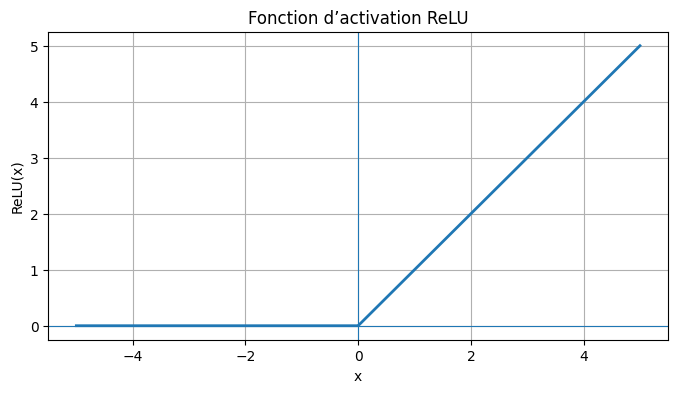

In [67]:
x = np.linspace(-5, 5, 500)
relu = np.maximum(0, x)

plt.figure(figsize=(8, 4))
plt.plot(x, relu, linewidth=2)
plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.xlabel('x')
plt.ylabel('ReLU(x)')
plt.title('Fonction d’activation ReLU')
plt.show()

### À retenir

ReLU est :

- simple ;
- rapide à calculer ;
- très couramment utilisée dans les couches cachées des réseaux neuronaux.

# 9. La fonction sigmoïde

Pour une classification binaire, une autre fonction importante est la sigmoïde :

$$
\sigma(x) = \frac{1}{1 + e^{-x}}
$$

Elle transforme une valeur quelconque en une valeur comprise entre 0 et 1, elle nous sera utile pour interpréter une valeur comme une probabilité.

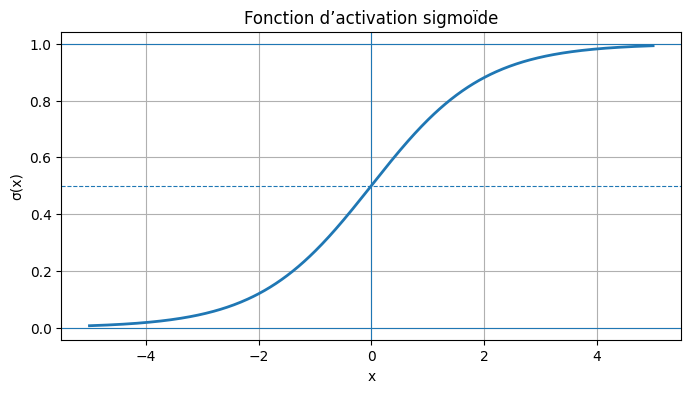

In [68]:
sigmoid = 1 / (1 + np.exp(-x))

plt.figure(figsize=(8, 4))
plt.plot(x, sigmoid, linewidth=2)

plt.axhline(0.5, linestyle='--', linewidth=0.8)
plt.axhline(0, linewidth=0.8)
plt.axhline(1, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.xlabel('x')
plt.ylabel('σ(x)')
plt.title('Fonction d’activation sigmoïde')
plt.show()

Quelques valeurs :

In [69]:
for value in [-4, -2, 0, 2, 4]:
    probability = 1 / (1 + np.exp(-value))
    print(f'x = {value:>2} → sigmoïde = {probability:.3f}')

x = -4 → sigmoïde = 0.018
x = -2 → sigmoïde = 0.119
x =  0 → sigmoïde = 0.500
x =  2 → sigmoïde = 0.881
x =  4 → sigmoïde = 0.982


On obtient des valeurs proches de :

```text
x très négatif → valeur proche de 0
x = 0          → 0.5
x très positif → valeur proche de 1
```

# 10. ReLU ou sigmoïde ?

Dans notre exemple de classification binaire :

```mermaid
flowchart TB
    HIDDEN_1["Couche cachée"] --> RELU_1["ReLU"]
    RELU_1 --> HIDDEN_2["Couche cachée"]
    HIDDEN_2 --> RELU_2["ReLU"]
    RELU_2 --> OUTPUT["Couche de sortie"]
    OUTPUT --> SIGMOID["Sigmoïde"]

    classDef layer fill:#E6F4F1,stroke:#138A72,color:#12453B,stroke-width:1.5px
    classDef activation fill:#F3F4F6,stroke:#64748B,color:#334155,stroke-width:1.5px
    classDef prediction fill:#FFF3D6,stroke:#C58A00,color:#5C4200,stroke-width:1.5px
    class HIDDEN_1,HIDDEN_2 layer
    class RELU_1,RELU_2 activation
    class OUTPUT,SIGMOID prediction
```

Une manière simple de retenir :

| Zone du réseau  | Fonction courante |
| --------------- | ----------------- |
| Couches cachées | ReLU              |
| Sortie binaire  | Sigmoïde          |

Ce choix dépend néanmoins du problème traité.

# 11. Architecture complète de notre exemple

Voici maintenant une architecture typique pour une classification binaire avec quatre variables d'entrée.

```mermaid
flowchart LR
    subgraph INPUT["Couche d'entrée"]
        I1["x₁"]
        I2["x₂"]
        I3["x₃"]
        I4["x₄"]
    end

    H1["16 neurones<br/>ReLU"]
    H2["8 neurones<br/>ReLU"]
    OUT["1 neurone<br/>Sigmoïde"]

    I1 --> H1
    I2 --> H1
    I3 --> H1
    I4 --> H1

    H1 --> H2
    H2 --> OUT

    classDef input fill:#E8F1FB,stroke:#2F6FED,color:#16345C,stroke-width:1.5px
    classDef model fill:#E6F4F1,stroke:#138A72,color:#12453B,stroke-width:1.5px
    classDef prediction fill:#FFF3D6,stroke:#C58A00,color:#5C4200,stroke-width:1.5px
    class I1,I2,I3,I4 input
    class H1,H2 model
    class OUT prediction
    style INPUT fill:#F4F8FE,stroke:#2F6FED,stroke-width:1.5px
```

En Keras, cela peut s'écrire :

In [70]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(16, activation='relu', input_shape=(4,)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.summary()

/Users/pierrejaumier/miniconda3/envs/tf/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225 (900.00 B)

 Trainable params: 225 (900.00 B)

 Non-trainable params: 0 (0.00 B)

# 12. Paramètres et hyperparamètres

Il faut distinguer deux notions.

## Paramètres appris

Le réseau apprend notamment :

- les poids ;
- les biais.

Ils sont modifiés pendant l'entraînement.

## Hyperparamètres

Nous choisissons notamment :

- le nombre de couches ;
- le nombre de neurones ;
- la fonction d'activation ;
- le nombre d'époques ;
- la taille des batches ;
- le taux d'apprentissage ;
- l'architecture générale.

```mermaid
flowchart TB
    subgraph DESIGN["Choisis par le concepteur"]
        A["Nombre de couches"]
        B["Nombre de neurones"]
        C["Fonctions d'activation"]
        D["Learning rate"]
        E["Nombre d'époques"]
        F["Batch size"]
    end

    subgraph LEARNED["Appris pendant l'entraînement"]
        G["Poids"]
        H["Biais"]
    end

    DESIGN --> G
    DESIGN --> H
    G --> PRED["Prédiction"]
    H --> PRED

    classDef design fill:#F3F4F6,stroke:#64748B,color:#334155,stroke-width:1.5px
    classDef learned fill:#E6F4F1,stroke:#138A72,color:#12453B,stroke-width:1.5px
    classDef prediction fill:#FFF3D6,stroke:#C58A00,color:#5C4200,stroke-width:1.5px
    class A,B,C,D,E,F design
    class G,H learned
    class PRED prediction
    style DESIGN fill:#F8FAFC,stroke:#64748B,stroke-width:1.5px
    style LEARNED fill:#F0FAF7,stroke:#138A72,stroke-width:1.5px
```

### Question

> **Le réseau apprend-il son architecture ?**

Non, dans cette approche classique, l'architecture est définie par le concepteur.

Le réseau apprend ses paramètres.

# 13. Comment le réseau apprend-il ?

C'est le cœur du fonctionnement.

Le processus général est :

```mermaid
flowchart LR
    DATA["Donnée x"] --> FORWARD["Propagation avant"]
    FORWARD --> PRED["Prédiction ŷ"]
    PRED --> LOSS["Calcul de la loss"]
    TARGET["Réponse attendue y"] --> LOSS
    LOSS --> GRAD["Calcul des gradients"]
    GRAD --> UPDATE["Mise à jour des paramètres"]
    UPDATE --> FORWARD

    classDef data fill:#E8F1FB,stroke:#2F6FED,color:#16345C,stroke-width:1.5px
    classDef process fill:#E6F4F1,stroke:#138A72,color:#12453B,stroke-width:1.5px
    classDef prediction fill:#FFF3D6,stroke:#C58A00,color:#5C4200,stroke-width:1.5px
    classDef error fill:#FDE8E7,stroke:#C2413B,color:#6B201C,stroke-width:1.5px
    classDef optimization fill:#EDEBFA,stroke:#5B4BB7,color:#30256B,stroke-width:1.5px
    class DATA,TARGET data
    class FORWARD,GRAD process
    class PRED prediction
    class LOSS error
    class UPDATE optimization
```

Le réseau répète ce cycle de nombreuses fois.

# 14. Étape 1 : propagation avant

On part d'une observation.

Les valeurs traversent successivement les couches.

```mermaid
flowchart TB
     INPUTS["Entrées"] --> LAYER_1["Couche 1"]
     LAYER_1 --> ACTIVATION_1["Activation"]
     ACTIVATION_1 --> LAYER_2["Couche 2"]
     LAYER_2 --> ACTIVATION_2["Activation"]
     ACTIVATION_2 --> OUTPUT["Sortie"]

     classDef input fill:#E8F1FB,stroke:#2F6FED,color:#16345C,stroke-width:1.5px
     classDef process fill:#E6F4F1,stroke:#138A72,color:#12453B,stroke-width:1.5px
     classDef prediction fill:#FFF3D6,stroke:#C58A00,color:#5C4200,stroke-width:1.5px
     class INPUTS input
     class LAYER_1,ACTIVATION_1,LAYER_2,ACTIVATION_2 process
     class OUTPUT prediction
```

Le résultat est une prédiction.

Pour une classification binaire :

```text
ŷ = 0.87
```

peut être interprété comme une probabilité associée à la classe positive.

# 15. Étape 2 : mesurer l'erreur

Nous comparons :

```text
Réponse attendue : y = 1

Prédiction :       ŷ = 0.87
```

La différence entre ce que le modèle prédit et ce qui est attendu est mesurée par une **fonction de perte**, ou `loss`.

Pour une classification binaire, une fonction courante est :

```text
binary cross-entropy
```

### Idée à retenir

> La fonction de perte fournit au réseau un moyen de mesurer à quel point sa prédiction est mauvaise.

# 16. Étape 3 : calculer les gradients

Une fois l'erreur calculée, nous voulons savoir :

> **Quels paramètres modifier et dans quelle direction ?**

C'est le rôle des gradients.

La rétropropagation, ou **backpropagation**, permet de calculer l'influence des paramètres sur la perte.

```mermaid
flowchart TB
    PREDICTION["Prédiction"] --> LOSS["Loss"]
    LOSS --> GRADIENTS["Gradients"]
    GRADIENTS --> WEIGHTS["Modification des poids"]

    classDef prediction fill:#FFF3D6,stroke:#C58A00,color:#5C4200,stroke-width:1.5px
    classDef error fill:#FDE8E7,stroke:#C2413B,color:#6B201C,stroke-width:1.5px
    classDef optimization fill:#EDEBFA,stroke:#5B4BB7,color:#30256B,stroke-width:1.5px
    class PREDICTION prediction
    class LOSS error
    class GRADIENTS,WEIGHTS optimization
```

Il n'est pas nécessaire de calculer ici manuellement toutes les dérivées.

L'idée essentielle est :

> Le gradient indique comment faire évoluer les paramètres pour réduire la perte.

# 17. Étape 4 : mise à jour des paramètres

L'optimiseur utilise les gradients pour modifier les paramètres.

Une représentation simplifiée est :

$$
w_{nouveau} = w_{ancien} - \eta \frac{\partial L}{\partial w}
$$

où :

- `w` est un paramètre ;
- `L` est la fonction de perte ;
- `η` est le taux d'apprentissage.

Le processus est répété :

```mermaid
flowchart TB
    PREDICTION["Prédiction"] --> ERROR["Erreur"]
    ERROR --> GRADIENT["Gradient"]
    GRADIENT --> UPDATE["Mise à jour"]
    UPDATE --> NEW_PREDICTION["Nouvelle prédiction"]
    NEW_PREDICTION --> NEXT_ERROR["Erreur suivante"]
    NEXT_ERROR -.-> GRADIENT

    classDef prediction fill:#FFF3D6,stroke:#C58A00,color:#5C4200,stroke-width:1.5px
    classDef error fill:#FDE8E7,stroke:#C2413B,color:#6B201C,stroke-width:1.5px
    classDef optimization fill:#EDEBFA,stroke:#5B4BB7,color:#30256B,stroke-width:1.5px
    class PREDICTION,NEW_PREDICTION prediction
    class ERROR,NEXT_ERROR error
    class GRADIENT,UPDATE optimization
```

# 18. Visualiser la descente de gradient

Pour comprendre l'idée, imaginons un problème extrêmement simple.

Nous cherchons la valeur de `w` qui minimise :

$$
L(w) = (w - 3)^2
$$

Le minimum se trouve en `w = 3`.

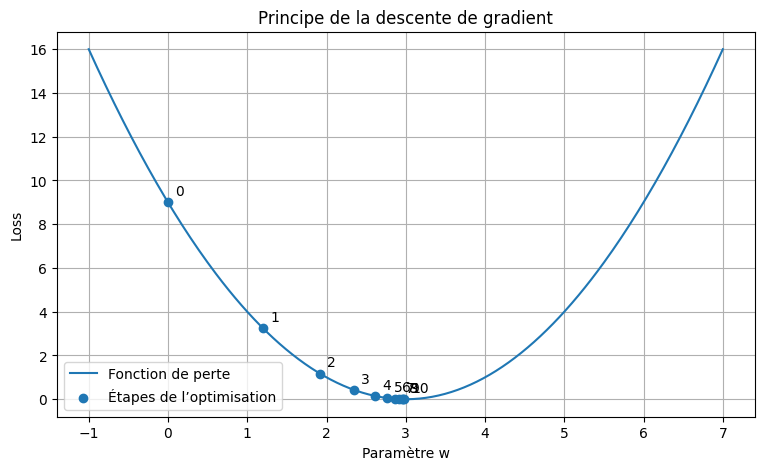

In [71]:
import matplotlib.pyplot as plt
w = 0.0
learning_rate = 0.2

weights = [w]
losses = [(w - 3) ** 2]

for _ in range(10):
    gradient = 2 * (w - 3)
    w = w - learning_rate * gradient

    weights.append(w)
    losses.append((w - 3) ** 2)

x_curve = np.linspace(-1, 7, 300)
y_curve = (x_curve - 3) ** 2

plt.figure(figsize=(9, 5))
plt.plot(
    x_curve,
    y_curve,
    label='Fonction de perte'
)
plt.scatter(
    weights,
    losses,
    zorder=3,
    label='Étapes de l’optimisation'
)

for i, (weight, loss) in enumerate(zip(weights, losses)):
    plt.annotate(
        str(i),
        (weight, loss),
        xytext=(5, 5),
        textcoords='offset points'
    )

plt.xlabel('Paramètre w')
plt.ylabel('Loss')
plt.title('Principe de la descente de gradient')
plt.legend()
plt.show()

### Interprétation

Le paramètre commence loin du minimum.

À chaque étape, l'optimisation tente de se rapprocher d'une valeur qui réduit la perte.

Dans un vrai réseau neuronal, le principe est identique, mais il existe beaucoup plus de paramètres.

# 19. L'optimiseur Adam

Dans de nombreux exemples Keras, on rencontre :

In [72]:
optimizer='adam'

Adam est une méthode d'optimisation largement utilisée pour entraîner des réseaux neuronaux.

Pour ce cours, retenons simplement :

> **L'optimiseur utilise les gradients pour ajuster progressivement les paramètres du modèle.**

Nous n'avons pas besoin de connaître les détails mathématiques d'Adam pour comprendre le fonctionnement global du réseau.

# 20. Epoch et batch

L'entraînement s'effectue généralement par lots.

## Batch

Un batch est un petit groupe d'observations utilisé pour calculer une mise à jour.

```mermaid
flowchart TB
    OBSERVATIONS["32 observations"] --> PREDICTIONS["Prédictions"]
    PREDICTIONS --> LOSS["Loss"]
    LOSS --> GRADIENT["Gradient"]
    GRADIENT --> UPDATE["Mise à jour"]

    classDef data fill:#E8F1FB,stroke:#2F6FED,color:#16345C,stroke-width:1.5px
    classDef prediction fill:#FFF3D6,stroke:#C58A00,color:#5C4200,stroke-width:1.5px
    classDef error fill:#FDE8E7,stroke:#C2413B,color:#6B201C,stroke-width:1.5px
    classDef optimization fill:#EDEBFA,stroke:#5B4BB7,color:#30256B,stroke-width:1.5px
    class OBSERVATIONS data
    class PREDICTIONS prediction
    class LOSS error
    class GRADIENT,UPDATE optimization
```

## Epoch

Une époque correspond à un passage complet sur les données d'entraînement.

In [73]:
epochs=30
batch_size=32

signifie notamment :

- 30 passages sur les données ;
- des groupes de 32 observations lors de l'apprentissage.

# 21. Préparer correctement les données

Les réseaux neuronaux sont sensibles aux échelles des variables.

Imaginons :

```text
âge          : 18 → 80
revenu       : 1 000 → 100 000
distance     : 0 → 500
```

Les variables n'ont pas des ordres de grandeur comparables.

Une étape fréquente consiste à standardiser les données.

In [74]:
from sklearn.preprocessing import StandardScaler
X = np.array([
    [20, 25000, 5],
    [35, 50000, 20],
    [60, 80000, 100],
    [45, 45000, 50]
])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Données originales :')
print(X)

print('\nDonnées standardisées :')
print(X_scaled)

Données originales :
[[   20 25000     5]
 [   35 50000    20]
 [   60 80000   100]
 [   45 45000    50]]

Données standardisées :
[[-1.37198868 -1.27000127 -1.06769671]
 [-0.34299717  0.         -0.65439476]
 [ 1.37198868  1.52400152  1.54988233]
 [ 0.34299717 -0.25400025  0.17220915]]


# 22. Attention aux fuites de données

La séparation entraînement/test doit avoir lieu **avant** l'ajustement du scaler.

```mermaid
flowchart LR
    DATA["Dataset"] --> SPLIT["Séparation train / test"]

    SPLIT --> TRAIN["Train"]
    SPLIT --> TEST["Test"]

    TRAIN --> FIT["fit du scaler"]
    FIT --> TRAIN_SCALE["Transformation du train"]

    FIT --> TEST_SCALE["Transformation du test"]
    TEST --> TEST_SCALE

    classDef data fill:#E8F1FB,stroke:#2F6FED,color:#16345C,stroke-width:1.5px
    classDef train fill:#E6F4F1,stroke:#138A72,color:#12453B,stroke-width:1.5px
    classDef test fill:#E8F5E9,stroke:#2E7D32,color:#1B5E20,stroke-width:1.5px
    class DATA,SPLIT data
    class TRAIN,FIT,TRAIN_SCALE train
    class TEST,TEST_SCALE test
```

Le principe :

```python
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
```

### Règle importante

> On apprend les paramètres de transformation sur le train, puis on applique cette transformation au test.

# 23. Pourquoi séparer entraînement et test ?

Si nous évaluons le modèle sur les données qu'il vient d'utiliser pour apprendre, l'évaluation peut être trompeuse.

Nous voulons savoir si le modèle sait généraliser.

```mermaid
flowchart TB
    DATASET["Dataset"] --> TRAIN["Train"]
    TRAIN --> LEARNING["Apprentissage"]
    LEARNING --> MODEL["Modèle"]
    DATASET --> TEST["Test"]
    TEST --> EVALUATION["Évaluation"]

    classDef data fill:#E8F1FB,stroke:#2F6FED,color:#16345C,stroke-width:1.5px
    classDef train fill:#E6F4F1,stroke:#138A72,color:#12453B,stroke-width:1.5px
    classDef test fill:#E8F5E9,stroke:#2E7D32,color:#1B5E20,stroke-width:1.5px
    class DATASET data
    class TRAIN,LEARNING,MODEL train
    class TEST,EVALUATION test
```

Le test représente donc des données que le modèle n'a pas utilisées directement pour ajuster ses paramètres.

# 24. Validation

Pendant l'entraînement, il est également utile de suivre un jeu de validation.

Une représentation possible est :

```mermaid
flowchart TB
    DATASET["Dataset d'origine"] --> TEST["Test final"]
    DATASET --> TRAINING_DATA["Données d'entraînement"]
    TRAINING_DATA --> TRAIN["Train"]
    TRAINING_DATA --> VALIDATION["Validation"]

    classDef data fill:#E8F1FB,stroke:#2F6FED,color:#16345C,stroke-width:1.5px
    classDef train fill:#E6F4F1,stroke:#138A72,color:#12453B,stroke-width:1.5px
    classDef test fill:#E8F5E9,stroke:#2E7D32,color:#1B5E20,stroke-width:1.5px
    class DATASET,TRAINING_DATA data
    class TRAIN,VALIDATION train
    class TEST test
```

La validation permet notamment de suivre le comportement du modèle pendant l'entraînement et de détecter des problèmes comme le surapprentissage.

# 25. Le surapprentissage

Un modèle peut devenir très performant sur les données d'entraînement tout en devenant moins performant sur de nouvelles données.

C'est le **surapprentissage**, ou `overfitting`.

Illustration :

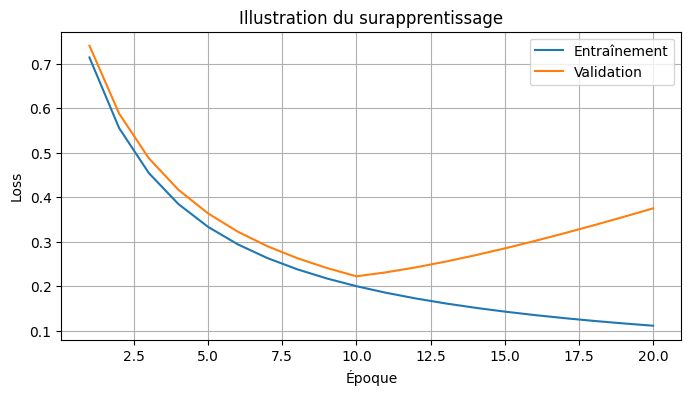

In [75]:
epochs = np.arange(1, 21)

train_loss = 1 / (epochs * 0.4 + 1)
val_loss = (
    1 / (epochs * 0.35 + 1)
    + np.maximum(epochs - 10, 0) * 0.025
)

plt.figure(figsize=(8, 4))
plt.plot(
    epochs,
    train_loss,
    label='Entraînement'
)
plt.plot(
    epochs,
    val_loss,
    label='Validation'
)

plt.xlabel('Époque')
plt.ylabel('Loss')
plt.title('Illustration du surapprentissage')
plt.legend()
plt.show()

### Question

À partir de quel moment le comportement de validation devient-il préoccupant ?

# 26. Sous-apprentissage et surapprentissage

On peut résumer trois situations :

```text
Sous-apprentissage
→ modèle trop simple

Bonne généralisation
→ modèle suffisamment complexe

Surapprentissage
→ modèle trop spécialisé sur les données d'entraînement
```

L'objectif n'est donc pas simplement de maximiser la performance sur le train.

L'objectif est d'obtenir un modèle qui généralise correctement.

# 27. Accuracy et loss

Pendant l'entraînement, deux indicateurs sont particulièrement faciles à observer.

## Loss

La loss mesure l'erreur selon la fonction de perte choisie.

En général :

> plus faible = mieux

## Accuracy

L'accuracy mesure la proportion de prédictions correctes.

Par exemple :

```text
100 observations
95 correctement classées

accuracy = 95 %
```

Attention :

> Une bonne accuracy ne signifie pas nécessairement que le modèle est adapté à tous les usages.

Il faut également examiner les différents types d'erreurs.

# 28. Exemple de classification non linéaire

Nous allons créer un petit jeu de données artificiel.

Le but est de visualiser pourquoi plusieurs couches peuvent être utiles.

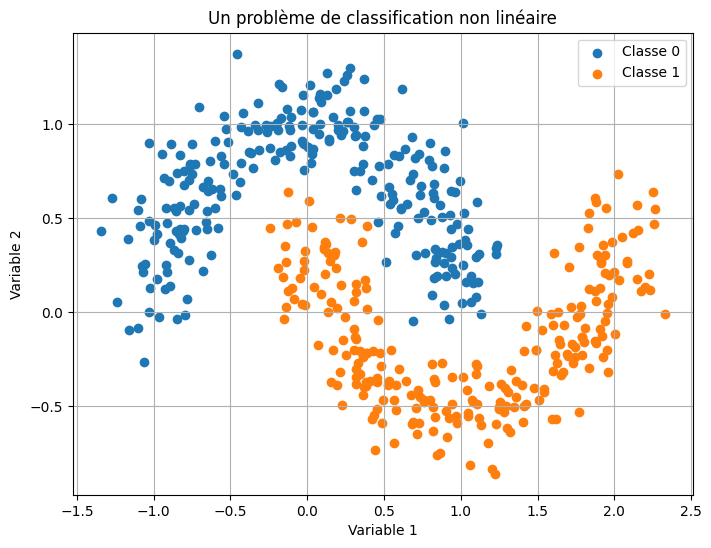

In [76]:
from sklearn.datasets import make_moons
X, y = make_moons(
    n_samples=500,
    noise=0.15,
    random_state=42
)

plt.figure(figsize=(8, 6))
plt.scatter(
    X[y == 0, 0],
    X[y == 0, 1],
    label='Classe 0'
)
plt.scatter(
    X[y == 1, 0],
    X[y == 1, 1],
    label='Classe 1'
)

plt.xlabel('Variable 1')
plt.ylabel('Variable 2')
plt.title('Un problème de classification non linéaire')
plt.legend()
plt.show()

### Question

Une seule droite pourrait-elle correctement séparer les deux classes ?

# 29. Une intuition des couches cachées

Une façon intuitive de comprendre les couches cachées est de les voir comme une succession de transformations.

```mermaid
flowchart TB
    RAW["Données originales"] --> SIMPLE_PATTERNS["Détection de motifs simples"]
    SIMPLE_PATTERNS --> COMBINED_PATTERNS["Combinaison de motifs"]
    COMBINED_PATTERNS --> COMPLEX_REPRESENTATION["Représentation plus complexe"]
    COMPLEX_REPRESENTATION --> DECISION["Décision finale"]

    classDef data fill:#E8F1FB,stroke:#2F6FED,color:#16345C,stroke-width:1.5px
    classDef process fill:#E6F4F1,stroke:#138A72,color:#12453B,stroke-width:1.5px
    classDef prediction fill:#FFF3D6,stroke:#C58A00,color:#5C4200,stroke-width:1.5px
    class RAW data
    class SIMPLE_PATTERNS,COMBINED_PATTERNS,COMPLEX_REPRESENTATION process
    class DECISION prediction
```

Il ne faut toutefois pas interpréter chaque neurone comme réalisant nécessairement une caractéristique humaine identifiable.

Les représentations apprises sont distribuées dans le réseau.

# 30. Construire un réseau avec Keras

Nous allons maintenant utiliser TensorFlow/Keras.

In [77]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

Nous pouvons construire un réseau :

In [78]:
model = Sequential([
    Dense(16, activation='relu', input_shape=(2,)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.summary()

/Users/pierrejaumier/miniconda3/envs/tf/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

Notre architecture est :

```mermaid
flowchart TB
     INPUTS["2 entrées"] --> HIDDEN_1["16 neurones - ReLU"]
     HIDDEN_1 --> HIDDEN_2["8 neurones - ReLU"]
     HIDDEN_2 --> OUTPUT["1 neurone - Sigmoïde"]

     classDef input fill:#E8F1FB,stroke:#2F6FED,color:#16345C,stroke-width:1.5px
     classDef model fill:#E6F4F1,stroke:#138A72,color:#12453B,stroke-width:1.5px
     classDef prediction fill:#FFF3D6,stroke:#C58A00,color:#5C4200,stroke-width:1.5px
     class INPUTS input
     class HIDDEN_1,HIDDEN_2 model
     class OUTPUT prediction
```

# 31. Compiler le modèle

Avant l'entraînement, nous devons définir comment le réseau sera entraîné.

In [79]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

Nous définissons notamment :

### `optimizer`

La méthode utilisée pour ajuster les paramètres.

### `loss`

La fonction utilisée pour mesurer l'erreur.

### `metrics`

Les indicateurs que nous souhaitons suivre.



# 32. Préparer le jeu de données

Séparons maintenant les données.

In [80]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 33. Entraîner le modèle

In [81]:
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

L'objet `history` conserve l'évolution des métriques.

# 34. Observer l'apprentissage

In [82]:
import pandas as pd
history_df = pd.DataFrame(history.history)

history_df.head()

,accuracy,loss,val_accuracy,val_loss
0,0.184375,0.842531,0.2125,0.789398
1,0.212500,0.804180,0.2750,0.756729
2,0.259375,0.770722,0.3375,0.727977
3,0.306250,0.741385,0.3875,0.701934
4,0.418750,0.712681,0.6125,0.677579


Visualisons l'accuracy.

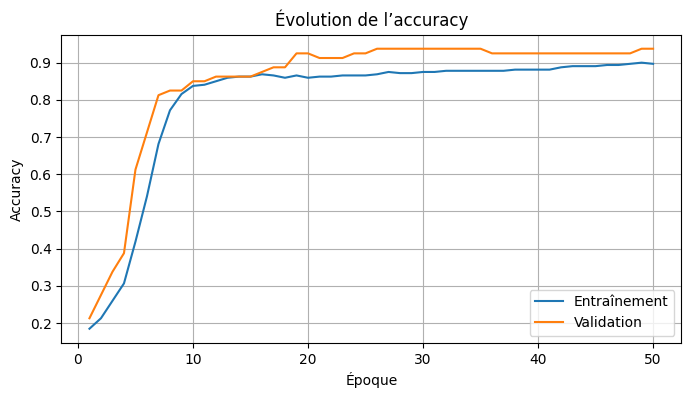

In [83]:
plt.figure(figsize=(8, 4))
plt.plot(
    history_df.index + 1,
    history_df['accuracy'],
    label='Entraînement'
)
plt.plot(
    history_df.index + 1,
    history_df['val_accuracy'],
    label='Validation'
)

plt.xlabel('Époque')
plt.ylabel('Accuracy')
plt.title('Évolution de l’accuracy')
plt.legend()
plt.show()

Puis la loss.

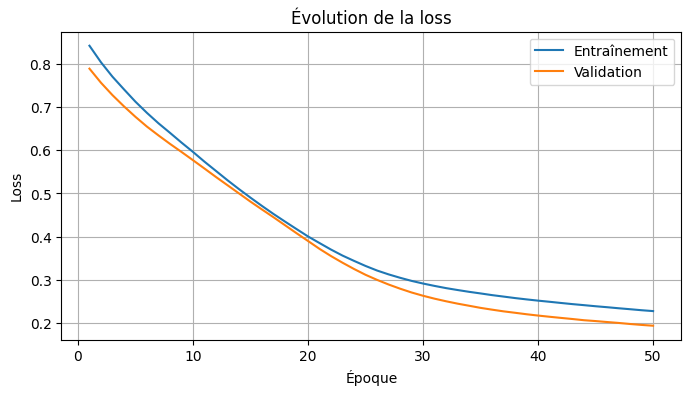

In [84]:
plt.figure(figsize=(8, 4))
plt.plot(
    history_df.index + 1,
    history_df['loss'],
    label='Entraînement'
)
plt.plot(
    history_df.index + 1,
    history_df['val_loss'],
    label='Validation'
)

plt.xlabel('Époque')
plt.ylabel('Loss')
plt.title('Évolution de la loss')
plt.legend()
plt.show()

# 35. Évaluer le modèle

Le jeu de test n'a pas servi directement à l'apprentissage.

Nous pouvons maintenant l'utiliser.

In [85]:
loss, accuracy = model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print(f'Loss sur le test : {loss:.4f}')
print(f'Accuracy sur le test : {accuracy:.2%}')

Loss sur le test : 0.2082
Accuracy sur le test : 90.00%


# 36. Examiner les prédictions

Le réseau retourne une probabilité.

In [86]:
y_proba = model.predict(
    X_test_scaled,
    verbose=0
).ravel()

print(y_proba[:10])

[0.9872511  0.04342673 0.55779135 0.9825518  0.9507355  0.67501295
 0.96498907 0.08558704 0.653515   0.54392505]


Pour obtenir une classe :

In [87]:
y_pred = (y_proba >= 0.5).astype(int)

print(y_pred[:10])

[1 0 1 1 1 1 1 0 1 1]


Le seuil de `0.5` est une convention de décision dans cet exemple.

Il ne faut pas confondre :

```mermaid
flowchart TB
    MODEL_OUTPUT["Sortie du modèle"] --> PROBABILITY["Probabilité"]
    PROBABILITY --> RULE["Règle de décision"]
    RULE --> CLASS["Classe"]

    classDef model fill:#E6F4F1,stroke:#138A72,color:#12453B,stroke-width:1.5px
    classDef prediction fill:#FFF3D6,stroke:#C58A00,color:#5C4200,stroke-width:1.5px
    classDef decision fill:#EDEBFA,stroke:#5B4BB7,color:#30256B,stroke-width:1.5px
    class MODEL_OUTPUT model
    class PROBABILITY prediction
    class RULE,CLASS decision
```

# 37. Observer la matrice de confusion

In [88]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[44  6]
 [ 4 46]]


Nous pouvons également la représenter.

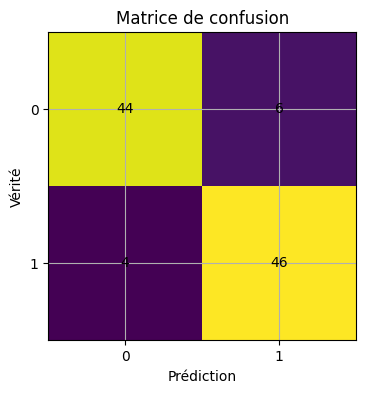

In [89]:
plt.figure(figsize=(5, 4))
plt.imshow(cm)

plt.title('Matrice de confusion')
plt.xlabel('Prédiction')
plt.ylabel('Vérité')

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i, j],
            ha='center',
            va='center'
        )

plt.xticks([0, 1])
plt.yticks([0, 1])
plt.show()

### Pourquoi regarder autre chose que l'accuracy ?

Deux modèles peuvent avoir la même accuracy tout en faisant des erreurs très différentes.

Selon le contexte métier, certaines erreurs peuvent être beaucoup plus importantes que d'autres.

# 38. Le seuil de décision

Le réseau produit une probabilité.

Nous pouvons choisir différents seuils :

In [90]:
thresholds = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

for threshold in thresholds:
    predictions = (y_proba >= threshold).astype(int)
    accuracy_threshold = accuracy_score(
        y_test,
        predictions
    )

    print(
        f'Seuil {threshold:.1f} '
        f'→ accuracy = {accuracy_threshold:.2%}'
    )

Seuil 0.2 → accuracy = 87.00%
Seuil 0.3 → accuracy = 88.00%
Seuil 0.4 → accuracy = 90.00%
Seuil 0.5 → accuracy = 90.00%
Seuil 0.6 → accuracy = 94.00%
Seuil 0.7 → accuracy = 90.00%
Seuil 0.8 → accuracy = 89.00%


### Question

Que se passe-t-il lorsque le seuil augmente ?

### Point important

Le réseau produit une sortie.

La manière dont cette sortie est transformée en décision dépend ensuite du problème et des objectifs.

# 39. Prédire une nouvelle observation

Imaginons une nouvelle observation.

In [91]:
new_observation = np.array([
    [1.2, -0.3]
])

Elle doit subir exactement la même transformation que les données d'entraînement.

In [92]:
new_observation_scaled = scaler.transform(
    new_observation
)

Puis nous pouvons demander une prédiction.

In [93]:
new_probability = model.predict(
    new_observation_scaled,
    verbose=0
)[0, 0]

print(
    f'Probabilité prédite : '
    f'{new_probability:.2%}'
)

Probabilité prédite : 96.58%


Et appliquer une règle de décision :

In [94]:
if new_probability >= 0.5:
    print('Classe prédite : 1')
else:
    print('Classe prédite : 0')

Classe prédite : 1


# 40. La chaîne complète

Nous pouvons maintenant résumer tout le fonctionnement.

```mermaid
flowchart LR
    A["Données"] --> B["Préparation"]
    B --> C["Architecture"]
    C --> D["Propagation avant"]
    D --> E["Prédiction"]
    E --> F["Loss"]
    F --> G["Backpropagation"]
    G --> H["Optimiseur"]
    H --> D

    E --> I["Évaluation"]
    I --> J["Inférence"]

    classDef data fill:#E8F1FB,stroke:#2F6FED,color:#16345C,stroke-width:1.5px
    classDef process fill:#F3F4F6,stroke:#64748B,color:#334155,stroke-width:1.5px
    classDef prediction fill:#FFF3D6,stroke:#C58A00,color:#5C4200,stroke-width:1.5px
    classDef error fill:#FDE8E7,stroke:#C2413B,color:#6B201C,stroke-width:1.5px
    classDef optimization fill:#EDEBFA,stroke:#5B4BB7,color:#30256B,stroke-width:1.5px
    class A,B data
    class C,D,I process
    class E,J prediction
    class F error
    class G,H optimization
```

# 41. Retour sur une démonstration métier

Nous pouvons maintenant relire une démonstration complète de réseau neuronal avec un vocabulaire différent.

Dans une application métier, on peut avoir :

```mermaid
flowchart TB
    BUSINESS_DATA["Données métier"] --> PREPARATION["Préparation"]
    PREPARATION --> MODEL["Réseau neuronal"]
    MODEL --> PREDICTION["Prédiction"]
    PREDICTION --> BUSINESS_DECISION["Décision métier"]

    classDef data fill:#E8F1FB,stroke:#2F6FED,color:#16345C,stroke-width:1.5px
    classDef process fill:#E6F4F1,stroke:#138A72,color:#12453B,stroke-width:1.5px
    classDef prediction fill:#FFF3D6,stroke:#C58A00,color:#5C4200,stroke-width:1.5px
    classDef decision fill:#EDEBFA,stroke:#5B4BB7,color:#30256B,stroke-width:1.5px
    class BUSINESS_DATA data
    class PREPARATION,MODEL process
    class PREDICTION prediction
    class BUSINESS_DECISION decision
```

Par exemple :

```mermaid
flowchart TB
    SOURCES["Capteurs, transactions, utilisateurs,<br/>images, textes, mesures"] --> MODEL["Modèle neuronal"]
    MODEL --> PROBABILITY["Probabilité"]
    PROBABILITY --> BUSINESS_RULE["Règle métier"]
    BUSINESS_RULE --> ACTION["Action ou alerte"]

    classDef data fill:#E8F1FB,stroke:#2F6FED,color:#16345C,stroke-width:1.5px
    classDef model fill:#E6F4F1,stroke:#138A72,color:#12453B,stroke-width:1.5px
    classDef prediction fill:#FFF3D6,stroke:#C58A00,color:#5C4200,stroke-width:1.5px
    classDef decision fill:#EDEBFA,stroke:#5B4BB7,color:#30256B,stroke-width:1.5px
    class SOURCES data
    class MODEL model
    class PROBABILITY prediction
    class BUSINESS_RULE,ACTION decision
```

La technologie peut changer.

Le principe général reste le même.



# 42. Les limites d'un réseau neuronal

Un réseau neuronal peut être très puissant, mais il ne résout pas automatiquement tous les problèmes.

La qualité du résultat dépend notamment :

- de la qualité des données ;
- de la représentativité des données ;
- de la qualité des variables ;
- de l'architecture ;
- des hyperparamètres ;
- de la qualité de l'évaluation.

Un réseau peut également :

- surapprendre ;
- produire des erreurs ;
- être difficile à interpréter ;
- être coûteux à entraîner ;
- nécessiter beaucoup de données selon le problème.

# 43. Réseau neuronal ≠ compréhension humaine

Un réseau neuronal apprend des relations statistiques à partir des données.

Il ne faut pas automatiquement interpréter sa sortie comme une compréhension humaine du phénomène.

```mermaid
flowchart TB
     DATA["Données"] --> PATTERNS["Relations statistiques apprises"]
     PATTERNS --> PREDICTION["Prédiction"]

     classDef data fill:#E8F1FB,stroke:#2F6FED,color:#16345C,stroke-width:1.5px
     classDef model fill:#E6F4F1,stroke:#138A72,color:#12453B,stroke-width:1.5px
     classDef prediction fill:#FFF3D6,stroke:#C58A00,color:#5C4200,stroke-width:1.5px
     class DATA data
     class PATTERNS model
     class PREDICTION prediction
```

La qualité du modèle dépend donc fortement de ce qu'il a appris à partir des données disponibles.

# 44. Les notions essentielles à retenir

## Un neurone

$$
z = \sum_i w_i x_i + b
$$

puis :

$$
y = f(z)
$$

## Une couche

Plusieurs neurones travaillent en parallèle.

## Un réseau

Plusieurs couches sont empilées.

## L'apprentissage

```mermaid
flowchart TB
    PREDICTION["Prédiction"] --> LOSS["Loss"]
    LOSS --> GRADIENT["Gradient"]
    GRADIENT --> UPDATE["Mise à jour des paramètres"]

    classDef prediction fill:#FFF3D6,stroke:#C58A00,color:#5C4200,stroke-width:1.5px
    classDef error fill:#FDE8E7,stroke:#C2413B,color:#6B201C,stroke-width:1.5px
    classDef optimization fill:#EDEBFA,stroke:#5B4BB7,color:#30256B,stroke-width:1.5px
    class PREDICTION prediction
    class LOSS error
    class GRADIENT,UPDATE optimization
```

## Les paramètres

- poids ;
- biais.

## Les hyperparamètres

- architecture ;
- nombre de neurones ;
- learning rate ;
- batch size ;
- epochs ;
- fonctions d'activation.

## La généralisation

Le modèle doit fonctionner sur des données qu'il n'a jamais vues.

# 45. Mini-quiz de fin

### Question 1

Que représente un poids dans un neurone ?

- A. Le nombre d'observations
- B. L'influence d'une entrée dans le calcul du neurone
- C. Le nombre de couches
- D. La valeur de la loss

### Question 2

Quel est le rôle d'une fonction d'activation ?

- A. Charger les données
- B. Introduire de la non-linéarité
- C. Séparer train et test
- D. Calculer uniquement l'accuracy

### Question 3

À quoi sert la fonction de perte ?

- A. Mesurer l'erreur du modèle
- B. Choisir le nombre de neurones
- C. Normaliser les données
- D. Séparer les données

### Question 4

Que fait la backpropagation ?

- A. Elle crée les données
- B. Elle calcule comment les paramètres contribuent à l'erreur
- C. Elle supprime les neurones
- D. Elle transforme les données en images

### Question 5

Pourquoi conserver un jeu de test séparé ?

- A. Pour augmenter artificiellement le nombre de données
- B. Pour tester la capacité de généralisation du modèle
- C. Pour calculer les poids manuellement
- D. Pour choisir les colonnes du dataset

# 46. À vous de jouer

Nous avons maintenant les bases nécessaires pour passer à la pratique.

Dans le TP, vous allez devoir :

1. explorer un dataset ;
2. préparer les données ;
3. construire un premier réseau ;
4. entraîner le modèle ;
5. observer son apprentissage ;
6. analyser ses erreurs ;
7. modifier son architecture ;
8. étudier l'effet des hyperparamètres ;
9. observer le surapprentissage ;
10. utiliser le modèle sur de nouvelles observations.

> **Objectif : ne pas seulement savoir écrire `model.fit()`, mais comprendre ce qui se passe lorsque cette ligne est exécutée.**


